In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df = pd.read_csv("Titanic-Dataset.csv")
df.columns = df.columns.str.strip()
original_shape = df.shape
print(df.head())
print(df.info())
print(df.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [52]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

In [53]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

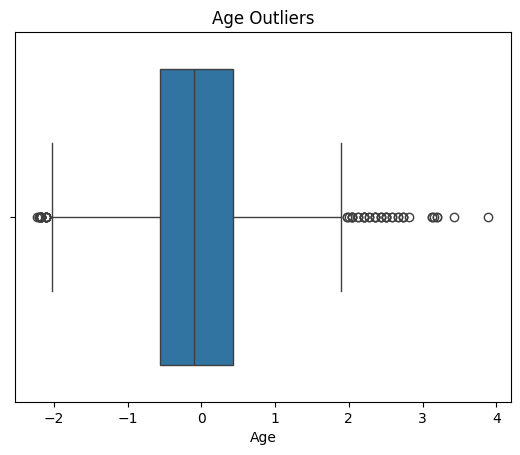

In [55]:
sns.boxplot(x=df['Age'])
plt.title("Age Outliers")
plt.show()

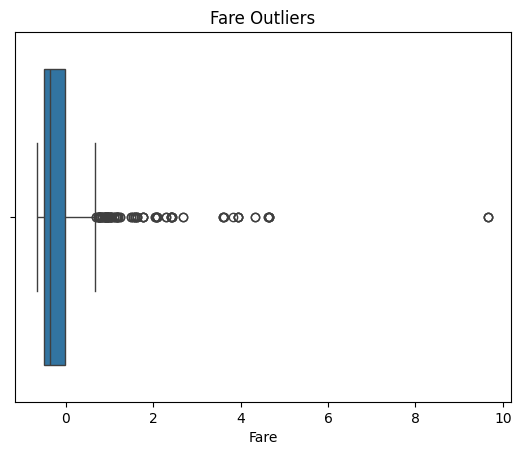

In [56]:
sns.boxplot(x=df['Fare'])
plt.title("Fare Outliers")
plt.show()

In [76]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Fare'] >= Q1 - 1.5*IQR) & (df['Fare'] <= Q3 + 1.5*IQR)]

print("Original Shape:", original_shape)
print("After Cleaning Shape:", df.shape)
print("Columns after preprocessing:", df.columns)
print(df.isnull().sum())
print(df.shape)
print(df.head())

Original Shape: (891, 12)
After Cleaning Shape: (720, 9)
Columns after preprocessing: Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64
(720, 9)
   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_Q  \
0         0       3    0 -0.565736      1      0 -0.502445       False   
2         1       3    1 -0.258337      0      0 -0.488854       False   
4         0       3    0  0.433312      0      0 -0.486337       False   
5         0       3    0 -0.104637      0      0 -0.478116        True   
7         0       3    0 -2.102733      3      1 -0.224083       False   

   Embarked_S  
0        True  
2        True  
4        True  
5       False  
7        True  


In [77]:
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True, errors='ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))



Accuracy: 0.8055555555555556


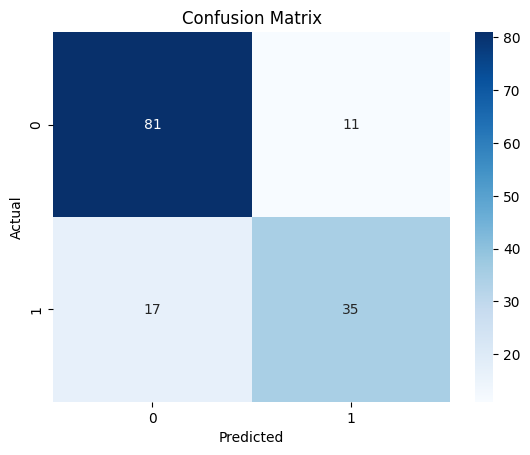

Final Shape: (720, 9)
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
dtype: int64
Accuracy check done ✔


In [78]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Final Shape:", df.shape)
print(df.isnull().sum())
print("Accuracy check done ✔")

In [79]:
print(df.head())
df.to_csv("cleaned_titanic.csv", index=False)

   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_Q  \
0         0       3    0 -0.565736      1      0 -0.502445       False   
2         1       3    1 -0.258337      0      0 -0.488854       False   
4         0       3    0  0.433312      0      0 -0.486337       False   
5         0       3    0 -0.104637      0      0 -0.478116        True   
7         0       3    0 -2.102733      3      1 -0.224083       False   

   Embarked_S  
0        True  
2        True  
4        True  
5       False  
7        True  
